
11490434/11490434 [==============================] - 8s 1us/step
Training data shape: (60000, 28, 28)
Testing data shape: (10000, 28, 28)


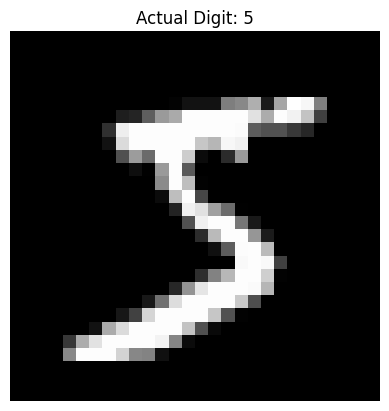


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 784)               0         
                                                                 
 dense (Dense)               (None, 512)               401920    
                                                                 
 dense_1 (Dense)             (None, 256)               131328    
                                                                 
 dense_2 (Dense)             (None, 128)               32896     
                                                                 
 dense_3 (Dense)             (None, 64)                8256      
                                                                 
 dense_4 (Dense)             (None, 10)                650       
                                                                 
Total params: 575050 (2.19 MB)
Trainable params: 575050

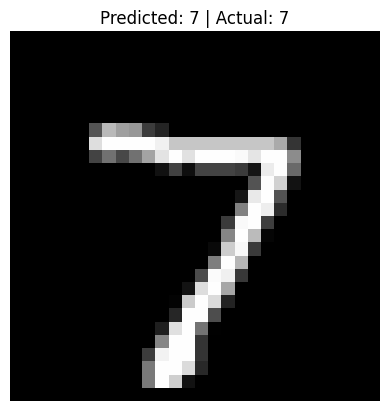

Image 1 | Predicted: 7 | Actual: 7
Image 2 | Predicted: 2 | Actual: 2
Image 3 | Predicted: 1 | Actual: 1
Image 4 | Predicted: 0 | Actual: 0
Image 5 | Predicted: 4 | Actual: 4
Image 6 | Predicted: 1 | Actual: 1
Image 7 | Predicted: 8 | Actual: 4
Image 8 | Predicted: 9 | Actual: 9
Image 9 | Predicted: 5 | Actual: 5
Image 10 | Predicted: 9 | Actual: 9


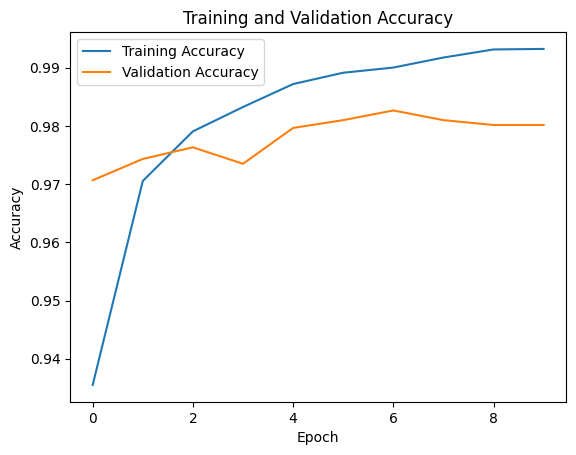

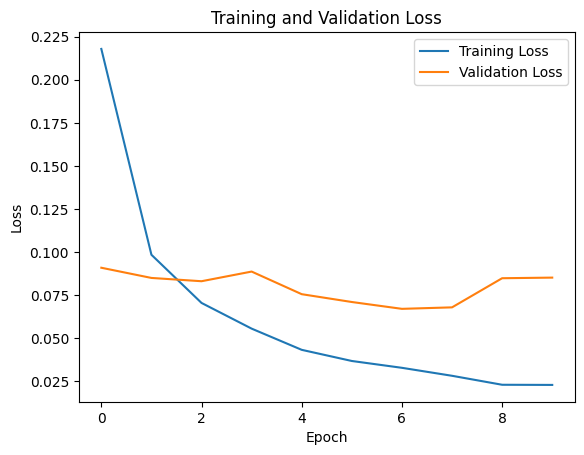

In [1]:
# ============================================================
# Experiment No. 3
# Deep Feed Forward ANN using Backpropagation
# Dataset: MNIST Handwritten Digits
# Hidden Layers: 4
# ============================================================

# Step 1: Import required libraries

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# Step 2: Load the MNIST Dataset
# ============================================================

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training data shape:", x_train.shape)
print("Testing data shape:", x_test.shape)


# ============================================================
# Step 3: Normalize the data
# ============================================================

x_train = x_train / 255.0
x_test = x_test / 255.0


# ============================================================
# Step 4: Display one sample image
# ============================================================

plt.imshow(x_train[0], cmap="gray")
plt.title("Actual Digit: " + str(y_train[0]))
plt.axis("off")
plt.show()


# ============================================================
# Step 5: Build the Deep Feed Forward ANN
# ============================================================

model = tf.keras.Sequential([

    # Input Layer: 28 x 28 = 784
    tf.keras.layers.Flatten(input_shape=(28, 28)),

    # Hidden Layer 1
    tf.keras.layers.Dense(512, activation="relu"),

    # Hidden Layer 2
    tf.keras.layers.Dense(256, activation="relu"),

    # Hidden Layer 3
    tf.keras.layers.Dense(128, activation="relu"),

    # Hidden Layer 4
    tf.keras.layers.Dense(64, activation="relu"),

    # Output Layer
    tf.keras.layers.Dense(10, activation="softmax")
])


# ============================================================
# Step 6: Display Model Architecture
# ============================================================

model.summary()


# ============================================================
# Step 7: Compile the model
# ============================================================

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


# ============================================================
# Step 8: Train the model
# ============================================================

history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)


# ============================================================
# Step 9: Evaluate the model
# ============================================================

test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test
)

print("\nTest Loss:", test_loss)
print("Test Accuracy:", test_accuracy)


# ============================================================
# Step 10: Make predictions
# ============================================================

predictions = model.predict(x_test)


# ============================================================
# Step 11: Display prediction for first test image
# ============================================================

predicted_digit = np.argmax(predictions[0])

print("\nPredicted Digit:", predicted_digit)
print("Actual Digit:", y_test[0])


# ============================================================
# Step 12: Display first test image
# ============================================================

plt.imshow(x_test[0], cmap="gray")

plt.title(
    "Predicted: " + str(predicted_digit) +
    " | Actual: " + str(y_test[0])
)

plt.axis("off")
plt.show()


# ============================================================
# Step 13: Display first 10 predictions
# ============================================================

for i in range(10):

    predicted_digit = np.argmax(predictions[i])

    print(
        "Image", i + 1,
        "| Predicted:", predicted_digit,
        "| Actual:", y_test[i]
    )


# ============================================================
# Step 14: Plot Training and Validation Accuracy
# ============================================================

plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend([
    "Training Accuracy",
    "Validation Accuracy"
])

plt.show()


# ============================================================
# Step 15: Plot Training and Validation Loss
# ============================================================

plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend([
    "Training Loss",
    "Validation Loss"
])

plt.show()